# PSA Dataset — Initial Cleaning & Curation (Week 1, Sub-objective 1)

**Pipeline:** text cleaning → drop empty English → deduplication → language detection (`langdetect`) → relevance filtering → English→Kiswahili translation (Google Translate) → summary statistics.

Implements the *"Perform initial cleaning: deduplication, language detection, relevance filtering"* milestone.

**Notes**
- No stemming / lemmatization is applied (kept intentionally, per requirement).
- Non-alphanumeric characters are stripped from all text columns; rows whose **English** cell becomes empty after cleaning are dropped.
- Empty **Kiswahili** cells are filled by translating the cleaned English with Google Translate.
- Every filtering step is auditable — dropped rows are saved to a separate file rather than silently discarded.

## 0. Install dependencies

Run once. Safe to skip if already installed.

In [1]:
#%pip install pandas langdetect deep-translator matplotlib
# If deep-translator's Google endpoint is blocked in your environment, the
# translation step includes a graceful fallback and can be re-run later.

## 1. Imports & configuration

All tunable knobs live here so you can adjust behaviour without hunting through the code.

In [2]:
import re
import time
import unicodedata
import pandas as pd

from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 42  # make language detection deterministic across runs

# ----------------------------- CONFIG ---------------------------------------
INPUT_CSV   = "merged_psa_dataset.csv"          # <-- path to your uploaded CSV
OUTPUT_CSV  = "psa_dataset_cleaned.csv"          # cleaned dataset
REVIEW_CSV  = "psa_dropped_for_review.csv"       # rows removed by filtering

# Text columns to clean (all natural-language columns in the corpus)
TEXT_COLS   = ["English", "Kiswahili"]

# Cleaning
KEEP_BASIC_PUNCTUATION = False   # False = strip ALL non-alphanumeric (per spec).
                                 # Set True to keep . , ! ? ; : ' " ( ) -

# Relevance filtering
MIN_WORDS            = 3    # English rows shorter than this are dropped
TRUST_LANG_MINWORDS  = 12   # only drop a row as "non-English" if it is at least
                            # this long (langdetect is unreliable on short,
                            # proper-noun-heavy text, so we stay conservative)
DROP_NON_ENGLISH     = True

# Translation
TRANSLATE_KISWAHILI  = True
MAX_TRANSLATIONS     = None   # e.g. 25 for a quick test run; None = translate all
TRANSLATE_SLEEP      = 0.0    # seconds between calls (raise if you hit rate limits)
# ----------------------------------------------------------------------------

## 2. Load the dataset

In [3]:
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Columns:", list(df.columns))

# Snapshot of missing values before cleaning
missing_before = df.isna().sum()
print("\nMissing values per column (before cleaning):")
print(missing_before.to_string())
df.head(3)

Loaded 6,236 rows x 11 columns
Columns: ['PSA_ID', 'Domain', 'English', 'Kiswahili', 'Ekegusii', 'Somali', 'Dholuo', 'Target_Languages', 'Source', 'Date', 'Metadata']

Missing values per column (before cleaning):
PSA_ID                 0
Domain                 0
English                0
Kiswahili           1900
Ekegusii            3163
Somali              3511
Dholuo              3514
Target_Languages    6103
Source                 0
Date                3107
Metadata             133


,PSA_ID,Domain,English,Kiswahili,Ekegusii,Somali,Dholuo,Target_Languages,Source,Date,Metadata
0,SEC_0001,Security & Safety,"At the UN High-Level Meeting, Eng. Nashon Kond...",Katika Mkutano wa Ngazi ya Juu wa Umoja wa Mat...,NaN,NaN,NaN,NaN,NTSA (National Transport and Safety Authority),2026-07-21,tone=advisory; platform=website; category=Road...
1,SEC_0002,Security & Safety,NTSA FACTS: Payment of Instant Fines.,UKWELI WA NTSA: Malipo ya Faini za Papo Hapo.,NaN,NaN,NaN,NaN,NTSA (National Transport and Safety Authority),2026-07-01,tone=advisory; platform=website; category=Serv...
2,SEC_0003,Security & Safety,The Authority has clarified the enforcement of...,Mamlaka imetoa ufafanuzi wa utekelezaji wa mah...,NaN,NaN,NaN,NaN,NTSA (National Transport and Safety Authority),2026-06-28,tone=advisory; platform=website; category=Noti...


## 3. Text cleaning

Each text cell is:
1. **Unicode-normalised** (`NFKC`) — folds stylised look-alike glyphs (e.g. the bold
   math letters `𝐎𝐃𝐏𝐏`) back to plain ASCII `ODPP` instead of deleting them.
2. Stripped of **URLs**, **@handles / #hashtags**, and **emoji / pictographs**.
3. Stripped of **non-alphanumeric characters** (whitespace is preserved so words stay separate).
4. Collapsed to single spaces and trimmed.

The regex is Unicode-aware (`\\w`), so accented letters used in Kiswahili / Somali / Dholuo / Ekegusii survive.

In [5]:
URL_RE    = re.compile(r"(https?://\S+|www\.\S+)")
HANDLE_RE = re.compile(r"[@#]\w+")
EMOJI_RE  = re.compile(
    "["
    "\U0001F300-\U0001FAFF"   # symbols, pictographs, emoji
    "\U00002600-\U000027BF"   # misc symbols & dingbats
    "\U0001F1E6-\U0001F1FF"   # regional indicators (flags)
    "\U00002190-\U000021FF"   # arrows
    "\U00002B00-\U00002BFF"   # misc symbols and arrows
    "\U0000FE00-\U0000FE0F"   # variation selectors
    "]+",
    flags=re.UNICODE,
)
if KEEP_BASIC_PUNCTUATION:
    STRIP_RE = re.compile(r"""[^\w\s.,!?;:'"()\-]""", flags=re.UNICODE)
else:
    STRIP_RE = re.compile(r"[^\w\s]", flags=re.UNICODE)
WS_RE = re.compile(r"\s+")


def clean_text(value):
    """Clean a single text value; returns '' for NaN / empty input."""
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    text = URL_RE.sub(" ", text)
    text = HANDLE_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = text.replace("_", " ")          # underscores -> spaces
    text = STRIP_RE.sub(" ", text)         # remove non-alphanumeric
    text = WS_RE.sub(" ", text).strip()    # collapse whitespace
    return text


for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print("Text cleaning applied to:", [c for c in TEXT_COLS if c in df.columns])
df[["PSA_ID", "English", "Kiswahili"]].head(3)

Text cleaning applied to: ['English', 'Kiswahili', 'Ekegusii', 'Somali', 'Dholuo']


,PSA_ID,English,Kiswahili
0,SEC_0001,At the UN High Level Meeting Eng Nashon Kondiw...,Katika Mkutano wa Ngazi ya Juu wa Umoja wa Mat...
1,SEC_0002,NTSA FACTS Payment of Instant Fines,UKWELI WA NTSA Malipo ya Faini za Papo Hapo
2,SEC_0003,The Authority has clarified the enforcement of...,Mamlaka imetoa ufafanuzi wa utekelezaji wa mah...


## 4. Drop rows with an empty English column

Rows whose **English** text is empty after cleaning (e.g. cells that were only emoji or punctuation) carry no usable source sentence and are removed.

In [6]:
before = len(df)
df = df[df["English"].str.strip() != ""].copy()
print(f"Dropped {before - len(df):,} rows with empty English. Remaining: {len(df):,}")

Dropped 0 rows with empty English. Remaining: 6,236


## 5. Deduplication

Exact duplicates are matched on a normalised (lower-cased, whitespace-trimmed) version of the cleaned English sentence. The first occurrence is kept.

In [7]:
before = len(df)
df["_norm_en"] = df["English"].str.lower().str.strip()
df = df.drop_duplicates(subset="_norm_en", keep="first").copy()
df = df.drop(columns="_norm_en")
print(f"Removed {before - len(df):,} duplicate English rows. Remaining: {len(df):,}")

Removed 59 duplicate English rows. Remaining: 6,177


## 6. Language detection (`langdetect`)

We tag each **English** cell with its detected language code and store it in a new
`English_lang` column. Text shorter than 10 characters is marked `unknown` because
detection is meaningless on such short strings.

> **Caveat:** `langdetect` is probabilistic and unreliable on short, proper-noun-heavy
> PSA headlines. The column is informational; the *filtering* step below only acts on
> it conservatively.

In [8]:
def detect_language(text):
    text = str(text).strip()
    if len(text) < 10:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["English_lang"] = df["English"].apply(detect_language)

print("Detected language distribution (top 10):")
print(df["English_lang"].value_counts().head(10).to_string())

Detected language distribution (top 10):
en    6076
fr      22
ca      15
ro      10
da       9
it       8
nl       8
sw       6
tl       3
et       3


## 7. Relevance filtering

A row is flagged for removal when either:
- its English text has **fewer than `MIN_WORDS` words** (too short to be a usable PSA), or
- it is **confidently non-English**: detected as a language other than English *and* long
  enough (`>= TRUST_LANG_MINWORDS` words) that we trust the detection.

Flagged rows are **not deleted blindly** — they are written to `REVIEW_CSV` so you can
audit them before finalising.

In [9]:
df["_wc"] = df["English"].str.split().apply(len)

too_short   = df["_wc"] < MIN_WORDS
non_english = (
    DROP_NON_ENGLISH
    & (df["English_lang"] != "en")
    & (df["English_lang"] != "unknown")
    & (df["_wc"] >= TRUST_LANG_MINWORDS)
)

df["drop_reason"] = ""
df.loc[too_short,   "drop_reason"] = "too_short"
df.loc[non_english, "drop_reason"] = "non_english"

dropped = df[df["drop_reason"] != ""].copy()
kept    = df[df["drop_reason"] == ""].copy()

print(f"Flagged too_short   : {int(too_short.sum()):,}")
print(f"Flagged non_english : {int(non_english.sum()):,}")
print(f"Total flagged       : {len(dropped):,}")
print(f"Rows kept           : {len(kept):,}")

# Save flagged rows for manual review
dropped.drop(columns=["_wc"]).to_csv(REVIEW_CSV, index=False)
print(f"\nFlagged rows saved to '{REVIEW_CSV}' for review.")

df = kept.drop(columns=["drop_reason", "_wc"]).copy()

Flagged too_short   : 3
Flagged non_english : 11
Total flagged       : 14
Rows kept           : 6,163

Flagged rows saved to 'psa_dropped_for_review.csv' for review.


## 8. Translate empty Kiswahili cells (English → Kiswahili)

Uses `deep-translator`'s `GoogleTranslator` (Google Translate backend, no API key needed).
Only rows with an **empty Kiswahili** cell are translated; existing translations are left
untouched. Features:
- long text is **chunked** under Google's ~5000-char per-request limit,
- each row is wrapped in **try/except** so one failure never aborts the batch,
- a `Kiswahili_source` column records whether a cell was `original` or `google_translate`,
- set `MAX_TRANSLATIONS` in the config to a small number first to test.

In [10]:
df["Kiswahili_source"] = df["Kiswahili"].apply(
    lambda x: "original" if str(x).strip() != "" else "pending"
)

if TRANSLATE_KISWAHILI:
    from deep_translator import GoogleTranslator

    translator = GoogleTranslator(source="en", target="sw")

    def translate_en_to_sw(text, max_chunk=4500):
        """Translate English -> Kiswahili, chunking long text on sentence-ish
        boundaries. Returns '' on failure so the caller can decide what to do."""
        text = str(text).strip()
        if not text:
            return ""
        try:
            if len(text) <= max_chunk:
                return translator.translate(text)
            # chunk long text
            chunks, current = [], ""
            for word in text.split():
                if len(current) + len(word) + 1 > max_chunk:
                    chunks.append(current)
                    current = word
                else:
                    current = f"{current} {word}".strip()
            if current:
                chunks.append(current)
            return " ".join(translator.translate(c) for c in chunks)
        except Exception as exc:            # network / rate-limit / API change
            print(f"  ! translation failed: {exc}")
            return ""

    to_translate = df.index[df["Kiswahili_source"] == "pending"].tolist()
    if MAX_TRANSLATIONS is not None:
        to_translate = to_translate[:MAX_TRANSLATIONS]

    print(f"Translating {len(to_translate):,} rows (English -> Kiswahili)...")
    done = 0
    for i, idx in enumerate(to_translate, 1):
        translated = translate_en_to_sw(df.at[idx, "English"])
        if translated:
            df.at[idx, "Kiswahili"] = translated
            df.at[idx, "Kiswahili_source"] = "google_translate"
            done += 1
        if TRANSLATE_SLEEP:
            time.sleep(TRANSLATE_SLEEP)
        if i % 100 == 0 or i == len(to_translate):
            print(f"  {i:,}/{len(to_translate):,} processed ({done:,} succeeded)")

    # anything still pending failed to translate
    df.loc[df["Kiswahili_source"] == "pending", "Kiswahili_source"] = "translation_failed"
    print(f"\nDone. {done:,} cells newly translated.")
else:
    print("Translation skipped (TRANSLATE_KISWAHILI = False).")

Translating 1,891 rows (English -> Kiswahili)...
  100/1,891 processed (100 succeeded)
  200/1,891 processed (200 succeeded)
  300/1,891 processed (300 succeeded)
  400/1,891 processed (400 succeeded)
  ! translation failed: HTTPSConnectionPool(host='translate.google.com', port=443): Max retries exceeded with url: /m?tl=sw&sl=en&q=Onion+farmers+are+encouraged+to+establish+a+consistent+planting+schedule+to+ensure+a+steady+income+and+supply+throughout+the+year+Aim+for+high+yields+of+20+to+40+tons+per+acre+for+better+profitability (Caused by NewConnectionError("HTTPSConnection(host='translate.google.com', port=443): Failed to establish a new connection: [WinError 10051] A socket operation was attempted to an unreachable network"))
  500/1,891 processed (499 succeeded)
  600/1,891 processed (599 succeeded)
  700/1,891 processed (699 succeeded)
  800/1,891 processed (799 succeeded)
  900/1,891 processed (899 succeeded)
  1,000/1,891 processed (999 succeeded)
  1,100/1,891 processed (1,099 s

## 9. Summary statistics

In [11]:
wc = lambda s: s.fillna("").astype(str).str.split().apply(len)

df["English_wc"]   = wc(df["English"])
df["Kiswahili_wc"] = wc(df["Kiswahili"])

total_rows = len(df)
print("=" * 60)
print("PSA DATASET — CLEANING SUMMARY")
print("=" * 60)
print(f"Total PSAs (rows) after cleaning : {total_rows:,}")
print()

# --- Rows per section (domain) ---
print("Rows per domain (section):")
dom = df["Domain"].value_counts()
for name, n in dom.items():
    print(f"  {name:<20} {n:>6,}  ({n/total_rows:5.1%})")
print()

# --- Word counts ---
total_en_words = int(df["English_wc"].sum())
total_sw_words = int(df["Kiswahili_wc"].sum())
print("Word counts:")
print(f"  Total English words           : {total_en_words:,}")
print(f"  Total Kiswahili words         : {total_sw_words:,}")
print(f"  Avg English words per PSA     : {df['English_wc'].mean():.1f}")
print(f"  Median English words per PSA  : {df['English_wc'].median():.0f}")
print(f"  Min / Max English words       : {df['English_wc'].min()} / {df['English_wc'].max()}")
print()

# --- Avg words per PSA by domain ---
print("Avg English words per PSA, by domain:")
for name, val in df.groupby("Domain")["English_wc"].mean().sort_values(ascending=False).items():
    print(f"  {name:<20} {val:6.1f}")
print()

# --- Translation / coverage per language ---
print("Translation coverage per target language:")
for col in ["Kiswahili", "Ekegusii", "Somali", "Dholuo"]:
    if col in df.columns:
        filled = (df[col].fillna("").astype(str).str.strip() != "").sum()
        print(f"  {col:<12} {filled:>6,} / {total_rows:,} filled ({filled/total_rows:5.1%})")
if "Kiswahili_source" in df.columns:
    print("\n  Kiswahili breakdown:")
    for src, n in df["Kiswahili_source"].value_counts().items():
        print(f"    {src:<20} {n:>6,}")
print("=" * 60)

# Tidy per-domain summary table
summary_table = (
    df.groupby("Domain")
      .agg(PSAs=("PSA_ID", "count"),
           English_words=("English_wc", "sum"),
           Avg_words_per_PSA=("English_wc", "mean"))
      .round(1)
      .sort_values("PSAs", ascending=False)
)
summary_table

PSA DATASET — CLEANING SUMMARY
Total PSAs (rows) after cleaning : 6,163

Rows per domain (section):
  Education             1,840  (29.9%)
  Agriculture           1,690  (27.4%)
  Security & Safety       977  (15.9%)
  Governance              883  (14.3%)
  Health                  773  (12.5%)

Word counts:
  Total English words           : 162,652
  Total Kiswahili words         : 169,935
  Avg English words per PSA     : 26.4
  Median English words per PSA  : 20
  Min / Max English words       : 3 / 3316

Avg English words per PSA, by domain:
  Education              38.5
  Agriculture            23.6
  Health                 23.2
  Governance             23.0
  Security & Safety      13.9

Translation coverage per target language:
  Kiswahili     6,161 / 6,163 filled (100.0%)
  Ekegusii      3,064 / 6,163 filled (49.7%)
  Somali        2,663 / 6,163 filled (43.2%)
  Dholuo        2,660 / 6,163 filled (43.2%)

  Kiswahili breakdown:
    original              4,272
    google_translat

,PSAs,English_words,Avg_words_per_PSA
Domain,,,
Education,1840,70931,38.5
Agriculture,1690,39934,23.6
Security & Safety,977,13585,13.9
Governance,883,20287,23.0
Health,773,17915,23.2


### Optional: quick visual of the summary

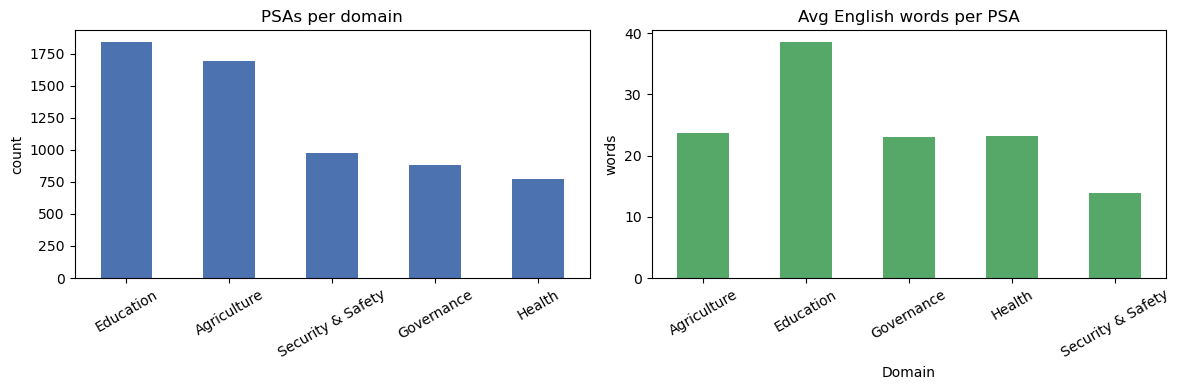

In [12]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    dom.plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("PSAs per domain"); axes[0].set_ylabel("count")
    axes[0].tick_params(axis="x", rotation=30)
    df.groupby("Domain")["English_wc"].mean().plot(kind="bar", ax=axes[1], color="#55A868")
    axes[1].set_title("Avg English words per PSA"); axes[1].set_ylabel("words")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed — skipping chart.")

## 10. Export the cleaned dataset

In [13]:
export_cols = [c for c in df.columns if c not in ("English_wc", "Kiswahili_wc")]
df[export_cols].to_csv(OUTPUT_CSV, index=False)
print(f"Cleaned dataset written to '{OUTPUT_CSV}'  ({len(df):,} rows, {len(export_cols)} columns)")
print(f"Flagged-for-review rows in     '{REVIEW_CSV}'")

Cleaned dataset written to 'psa_dataset_cleaned.csv'  (6,163 rows, 13 columns)
Flagged-for-review rows in     'psa_dropped_for_review.csv'
